# Rossi et al. (2006) Section 5.5.3 — Margarine Hierarchical MNL
## Replication of Figure 5.6: One- vs Five-Component Normal Mixture

This notebook loads the MCMC draws saved by `bayesm_both_models.R` and
replicates Figure 5.6 from the textbook.

**Posterior mean marginal density** (eq. 5.5.19):
$$\bar{d}_j(\beta_j) = \frac{1}{R} \sum_{r=1}^{R} \sum_{k=1}^{K} \text{pvec}_k^r \cdot \phi_j(\beta_j \mid \mu_{kj}^r, \Sigma_k^r[j,j])$$


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from pathlib import Path

# ── Path to R output CSVs (adjust if needed) ──────────────────────────────────
DATA_DIR = Path("Data")

PARAM_NAMES = [
    "Blue Bonnett Int",
    "Fleischmanns Int",
    "House Int",
    "Generic Int",
    "Shed Spread Int",
    "Price",
]
NVAR = 6

print("Packages loaded. DATA_DIR:", DATA_DIR.resolve())

Packages loaded. DATA_DIR: C:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\NormalMixture\margarine_paper\Data


## 1. Load MCMC draws

In [33]:
def load_model_draws(tag, ncomp, nvar=6):
    """
    Load CSVs saved by bayesm_both_models.R.
    Returns:
        pvec      : (n_samples, ncomp)
        mu        : (n_samples, ncomp, nvar)
        sigma_diag: (n_samples, ncomp, nvar)   marginal variances
    """
    pvec_df       = pd.read_csv(DATA_DIR / f"pvec_{tag}.csv")
    mu_df         = pd.read_csv(DATA_DIR / f"mu_{tag}.csv")
    sigma_diag_df = pd.read_csv(DATA_DIR / f"sigma_diag_{tag}.csv")

    n_samples = len(pvec_df)

    pvec       = pvec_df.values.astype(float)          # (n_samples, ncomp)
    mu_flat    = mu_df.values.astype(float)             # (n_samples, ncomp*nvar)
    sd_flat    = sigma_diag_df.values.astype(float)

    # Reshape to (n_samples, ncomp, nvar)
    # Column order: k1_v1 .. k1_v6, k2_v1 .. k2_v6, ...
    mu         = mu_flat.reshape(n_samples, ncomp, nvar)
    sigma_diag = sd_flat.reshape(n_samples, ncomp, nvar)

    print(f"  {tag}: {n_samples:,} draws, {ncomp} component(s)")
    return pvec, mu, sigma_diag


print("Loading K=1 ...")
pvec_K1, mu_K1, sd_K1 = load_model_draws("K1", ncomp=1)

print("Loading K=5 ...")
pvec_K5, mu_K5, sd_K5 = load_model_draws("K5", ncomp=5)

Loading K=1 ...
  K1: 18,000 draws, 1 component(s)
Loading K=5 ...
  K5: 18,000 draws, 5 component(s)


## 2. Posterior mean marginal density (eq. 5.5.19)

In [34]:
def posterior_marginal_density(grid, pvec, mu, sigma_diag, j):
    """
    Compute the posterior mean marginal density for parameter j.

    d̄_j(β_j) = (1/R) Σ_r Σ_k pvec_k^r · N(β_j | μ_kj^r, σ_kjj^r)

    Fully vectorised over draws and components.

    Parameters
    ----------
    grid       : (G,)  evaluation points
    pvec       : (R, K)
    mu         : (R, K, nvar)
    sigma_diag : (R, K, nvar)  marginal variances (not std-devs!)
    j          : int  parameter index
    """
    R, K = pvec.shape
    G    = len(grid)

    mu_j  = mu[:, :, j]                      # (R, K)
    std_j = np.sqrt(sigma_diag[:, :, j])     # (R, K)

    # Broadcast: (R, K, 1) vs (1, 1, G)  → pdf shape (R, K, G)
    pdf = norm.pdf(
        grid[np.newaxis, np.newaxis, :],       # (1, 1, G)
        mu_j[:, :, np.newaxis],                # (R, K, 1)
        std_j[:, :, np.newaxis]                # (R, K, 1)
    )

    # Weight by mixture probabilities and average over draws
    density = (pvec[:, :, np.newaxis] * pdf).sum(axis=1).mean(axis=0)  # (G,)
    return density


def auto_grid(mu, sigma_diag, j, n_points=400, z=4.0):
    """Build an evaluation grid spanning the posterior support for parameter j."""
    all_mu  = mu[:, :, j].ravel()
    all_std = np.sqrt(sigma_diag[:, :, j]).ravel()
    lo = (all_mu - z * all_std).min()
    hi = (all_mu + z * all_std).max()
    return np.linspace(lo, hi, n_points)


print("Helper functions defined.")

Helper functions defined.


## 3. Compute densities for all 6 parameters

In [35]:
# Use the union of K1 and K5 support for each parameter so both
# curves are plotted on the same x-axis.

results = []
for j, name in enumerate(PARAM_NAMES):
    grid_K1 = auto_grid(mu_K1, sd_K1, j, z=4.0)
    grid_K5 = auto_grid(mu_K5, sd_K5, j, z=4.0)

    lo = min(grid_K1[0],  grid_K5[0])
    hi = max(grid_K1[-1], grid_K5[-1])
    grid = np.linspace(lo, hi, 500)

    d_K1 = posterior_marginal_density(grid, pvec_K1, mu_K1, sd_K1, j)
    d_K5 = posterior_marginal_density(grid, pvec_K5, mu_K5, sd_K5, j)

    results.append(dict(name=name, grid=grid, d_K1=d_K1, d_K5=d_K5))
    print(f"  {name:25s}  x=[{lo:6.2f}, {hi:5.2f}]")

print("\nDone computing densities.")

  Blue Bonnett Int           x=[-375.47, 355.66]
  Fleischmanns Int           x=[-319.89, 218.45]
  House Int                  x=[-255.52, 168.43]
  Generic Int                x=[-241.96, 333.83]
  Shed Spread Int            x=[-291.90, 260.25]
  Price                      x=[-431.36, 225.10]

Done computing densities.


## 4. Figure 5.6 — One- and Five-Component Mixtures

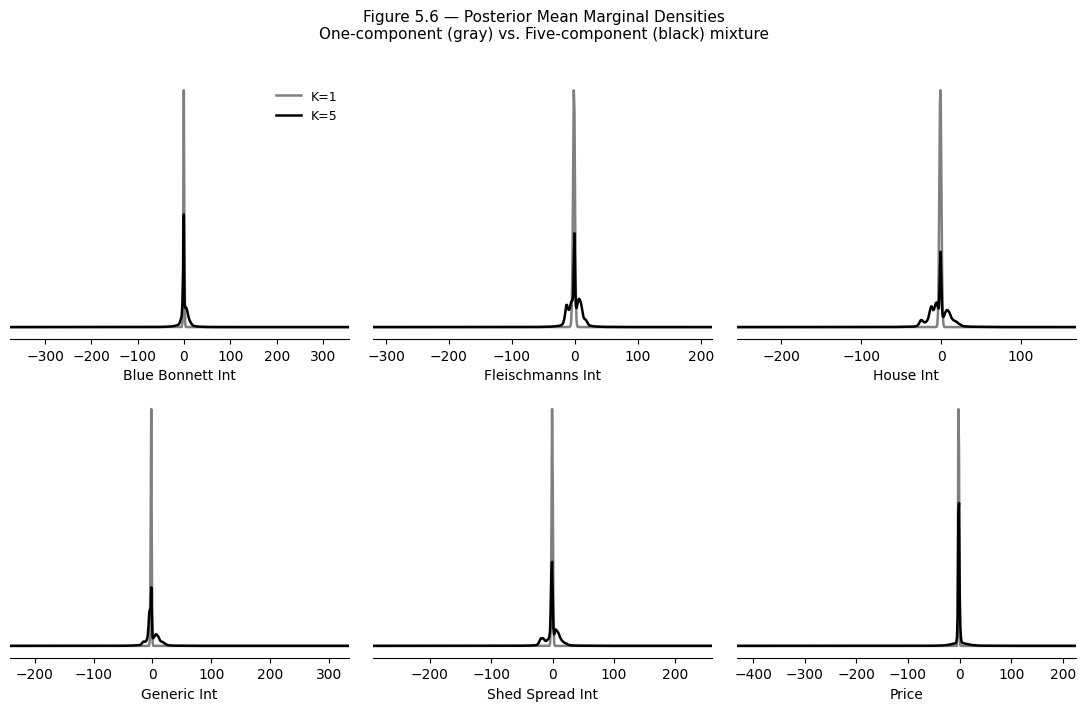

Saved figure_5_6_replication.png


In [36]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes = axes.flatten()

for ax, r in zip(axes, results):
    ax.plot(r["grid"], r["d_K1"], color="gray",  lw=1.8, label="K=1")
    ax.plot(r["grid"], r["d_K5"], color="black", lw=1.8, label="K=5")

    ax.set_xlabel(r["name"], fontsize=10)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.set_xlim(r["grid"][0], r["grid"][-1])

axes[0].legend(frameon=False, fontsize=9)

fig.suptitle(
    "Figure 5.6 — Posterior Mean Marginal Densities\n"
    "One-component (gray) vs. Five-component (black) mixture",
    fontsize=11, y=1.01
)
fig.tight_layout()
plt.savefig("figure_5_6_replication.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure_5_6_replication.png")

## 5. Posterior summary statistics

In [37]:
# For K=1 the single component mean IS the population mean.
# For K=5 the population mean is the pvec-weighted average of component means.

def pop_mean_draws(pvec, mu):
    """(R, nvar) array of draw-level population means."""
    # pvec: (R, K),  mu: (R, K, nvar)
    return (pvec[:, :, np.newaxis] * mu).sum(axis=1)   # (R, nvar)


pm_K1 = pop_mean_draws(pvec_K1, mu_K1)   # (R, 6)
pm_K5 = pop_mean_draws(pvec_K5, mu_K5)

rows = []
for j, name in enumerate(PARAM_NAMES):
    rows.append({
        "Parameter"    : name,
        "K=1 post.mean": f"{pm_K1[:, j].mean():.3f}",
        "K=1 post.std" : f"{pm_K1[:, j].std():.3f}",
        "K=5 post.mean": f"{pm_K5[:, j].mean():.3f}",
        "K=5 post.std" : f"{pm_K5[:, j].std():.3f}",
    })

summary = pd.DataFrame(rows).set_index("Parameter")
print(summary.to_string())

                 K=1 post.mean K=1 post.std K=5 post.mean K=5 post.std
Parameter                                                             
Blue Bonnett Int        -0.468        0.051         0.908        4.445
Fleischmanns Int        -1.370        0.294        -0.280        4.523
House Int               -0.993        0.075        -2.260        4.750
Generic Int             -2.025        0.128        -0.361        4.430
Shed Spread Int         -0.706        0.133        -0.414        4.828
Price                   -1.912        0.085        -1.230        4.290


## 6. Mixture weight diagnostics (K=5)

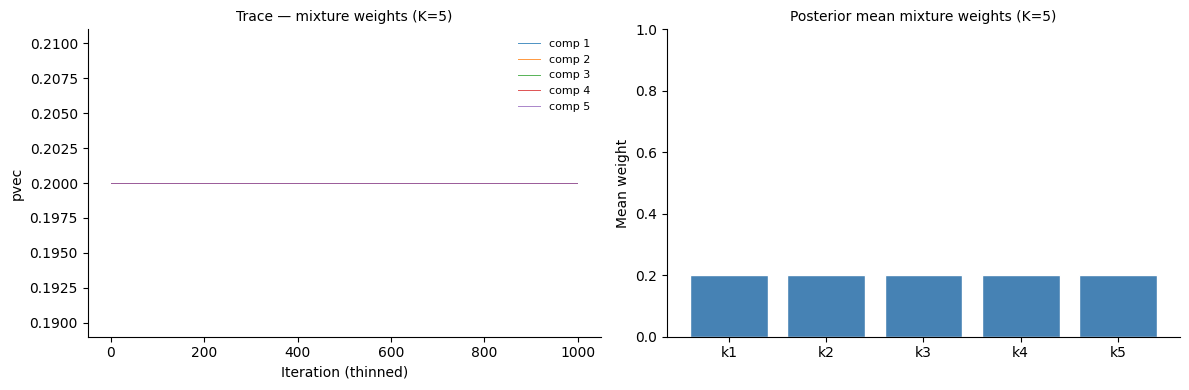

Saved mixture_weight_diagnostics.png


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── (a) Trace of each component weight ────────────────────────────────────────
ax = axes[0]
thin = max(1, len(pvec_K5) // 1000)   # thin to ≤1000 points for speed
for k in range(5):
    ax.plot(pvec_K5[::thin, k], lw=0.7, alpha=0.8, label=f"comp {k+1}")
ax.set_title("Trace — mixture weights (K=5)", fontsize=10)
ax.set_xlabel("Iteration (thinned)")
ax.set_ylabel("pvec")
ax.legend(fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# ── (b) Posterior mean of each component weight ───────────────────────────────
ax = axes[1]
mean_pvec = pvec_K5.mean(axis=0)
ax.bar([f"k{k+1}" for k in range(5)], mean_pvec, color="steelblue", edgecolor="white")
ax.set_title("Posterior mean mixture weights (K=5)", fontsize=10)
ax.set_ylabel("Mean weight")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.savefig("mixture_weight_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved mixture_weight_diagnostics.png")

## 7. K=5 Component means — posterior medians

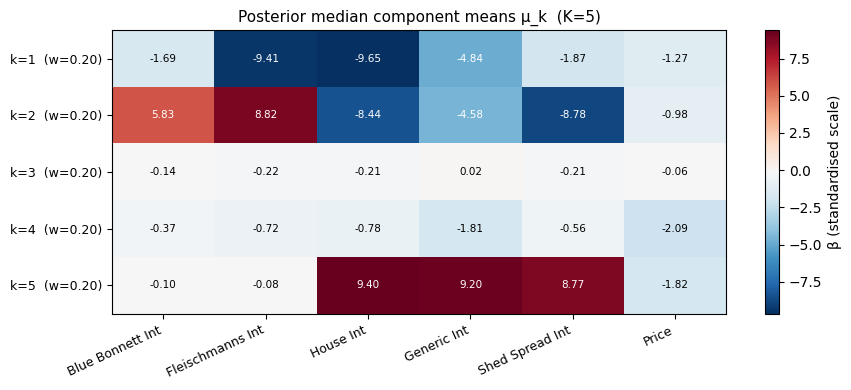

Saved component_means_heatmap.png


In [39]:
# Heatmap of posterior median component means
import matplotlib.colors as mcolors

med_mu = np.median(mu_K5, axis=0)   # (5, 6)
weight = pvec_K5.mean(axis=0)        # (5,)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(med_mu, aspect="auto", cmap="RdBu_r")

ax.set_xticks(range(NVAR))
ax.set_xticklabels(PARAM_NAMES, rotation=25, ha="right", fontsize=9)
ax.set_yticks(range(5))
ax.set_yticklabels(
    [f"k={k+1}  (w={w:.2f})" for k, w in enumerate(weight)], fontsize=9
)
ax.set_title("Posterior median component means μ_k  (K=5)", fontsize=11)

for i in range(5):
    for j in range(NVAR):
        ax.text(j, i, f"{med_mu[i, j]:.2f}",
                ha="center", va="center", fontsize=7.5,
                color="white" if abs(med_mu[i, j]) > 3 else "black")

plt.colorbar(im, ax=ax, label="β (standardised scale)")
fig.tight_layout()
plt.savefig("component_means_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved component_means_heatmap.png")

## 8. Side-by-side panel: marginal densities on book-style axes

Recreates the exact 2×3 layout of Figure 5.6 with shading.

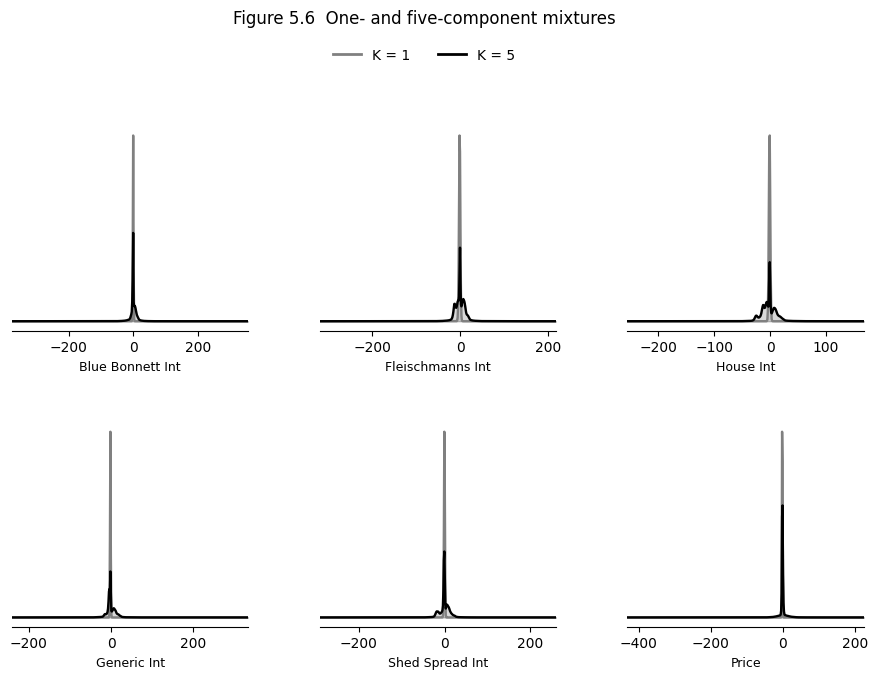

Saved figure_5_6_final.png


In [40]:
fig = plt.figure(figsize=(11, 6.5))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)

for idx, (r, ax_pos) in enumerate(zip(results, gs)):
    ax = fig.add_subplot(ax_pos)
    g, d1, d5 = r["grid"], r["d_K1"], r["d_K5"]

    ax.fill_between(g, d1, alpha=0.15, color="gray")
    ax.fill_between(g, d5, alpha=0.15, color="black")
    ax.plot(g, d1, color="gray",  lw=1.7)
    ax.plot(g, d5, color="black", lw=1.7)

    ax.set_xlabel(r["name"], fontsize=9)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.set_xlim(g[0], g[-1])

# Single shared legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="gray",  lw=2, label="K = 1"),
    Line2D([0], [0], color="black", lw=2, label="K = 5"),
]
fig.legend(handles=legend_elements, loc="upper center",
           ncol=2, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 1.02))

fig.suptitle("Figure 5.6  One- and five-component mixtures",
             fontsize=12, y=1.06)

plt.savefig("figure_5_6_final.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved figure_5_6_final.png")